## ELASTİC NET WİTH GRİD SEARCH

In [2]:
#Gerekli kütüphanelerin indirilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [3]:
# Veri setini indirelim.
veri= pd.read_excel("https://www.dropbox.com/s/luoopt5biecb04g/SATILK_EV1.xlsx?dl=1",index_col=0)
veri.head()

,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
0,475,1,40,0,6
1,475,1,55,0,5
2,450,1,50,0,7
3,450,1,55,1,6
4,475,1,45,2,7


In [4]:
# Hedef ve öznitelik değişkenlerini (x) tanımlayalım,Veriyi bölelim:
x=veri [["Oda_Sayısı","Net_m2","Katı","Yaşı"]]
y=veri["Fiyat"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
#Algoritmayı seçip parametrelere alternatif değer üretelim:
enet=ElasticNet(random_state=42)
parametreler={"alpha":[1e-15,1e-10,1e-8,1e-4,1e-3,1e-2,1,2,3,4,5,10,20,30,50],
              "l1_ratio":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]}


In [6]:
#parametreleri tanımlayalım:
enet_gs=GridSearchCV(enet,parametreler,scoring="r2",cv=5)


In [7]:
#modeli egitelim.
enet_gs.fit(x_train,y_train)

c:\Users\enesc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.974e+05, tolerance: 1.557e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\enesc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.192e+05, tolerance: 1.481e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linea

GridSearchCV(cv=5, estimator=ElasticNet(random_state=42),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   2, 3, 4, 5, 10, 20, 30, 50],
                         'l1_ratio': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                                      0.9, 1]},
             scoring='r2')

In [8]:
#Elastiknet için en iyi modelin alpha ve l1 degerleri
print(enet_gs.best_params_)

{'alpha': 0.01, 'l1_ratio': 0.5}


In [9]:
#diger en iyi parametreler.
print(enet_gs.best_estimator_)

ElasticNet(alpha=0.01, random_state=42)


In [10]:
# 5 adet r2nin ortlaama r2 scoru
print(enet_gs.best_score_)

0.7073610834707612


In [11]:
#Çapraz doğrulama (cross-validation)
all_accuracies=cross_val_score(estimator=enet_gs.best_estimator_,X=x_train,y=y_train,cv=5)

In [12]:
#Çapraz doğrulama sonuçları:
print("score",all_accuracies) #  farklı denemedeki score değerleri

print("ortalama r2",all_accuracies.mean())#ortalama başarı
print("standart sapma",all_accuracies.std())#standart sapma yani ne kadar skorların dalgalandığını söyler.

score [0.58966797 0.86205089 0.75871268 0.59061914 0.73575473]
ortalama r2 0.7073610834707612
standart sapma 0.10474012760014138


In [13]:
#tahmin modelinin kaysaıları
#elastic netin ürettiği en iyi modelin tahmin parametreleri:
sabit=enet_gs.best_estimator_.intercept_
print("sabit deger:",sabit)

oznitelik_katsayilari=pd.DataFrame(
                                   enet_gs.best_estimator_.coef_,x.columns,
                                   columns=['enet (a=1)öznitelik kaysayilari']
                                    )        
oznitelik_katsayilari

sabit deger: 296.9768160015013


,enet (a=1)öznitelik kaysayilari
Oda_Sayısı,110.067352
Net_m2,1.403373
Katı,7.126647
Yaşı,-4.328035


In [14]:
#en iyi enet modelinin eğitim ve test seti üzerindeki performanısna bakalım
enet_train_score=enet_gs.best_estimator_.score(x_train,y_train)
enet_test_score=enet_gs.best_estimator_.score(x_test,y_test)
print("Eğitim seti için R2:",enet_train_score)
print("Test seti için R2:",enet_test_score)

Eğitim seti için R2: 0.7333501064823666
Test seti için R2: 0.6923107858960039


In [15]:
#Tahmin modeli ile tüm veri seti için ev fiyatlarını tahmmin edelim:
veri['Fiyat_Tahmini']=enet_gs.best_estimator_.predict(x)

In [16]:
#Tahmin edilen ve gerçek ev fiyatları ilk 20 sine bakalım:
print(veri[["Fiyat","Fiyat_Tahmini",]].head(20))

    Fiyat  Fiyat_Tahmini
0     475     437.210859
1     475     462.589482
2     450     446.916549
3     450     465.388095
4     475     454.152981
5     475     458.261447
6     475     469.606345
7     475     446.916549
8     450     453.933412
9     475     455.792189
10    475     444.227722
11    525     532.476982
12    550     562.512995
13    575     506.769005
14    550     518.553041
15    575     532.916121
16    500     519.862895
17    550     474.263734
18    525     488.297460
19    500     498.702522


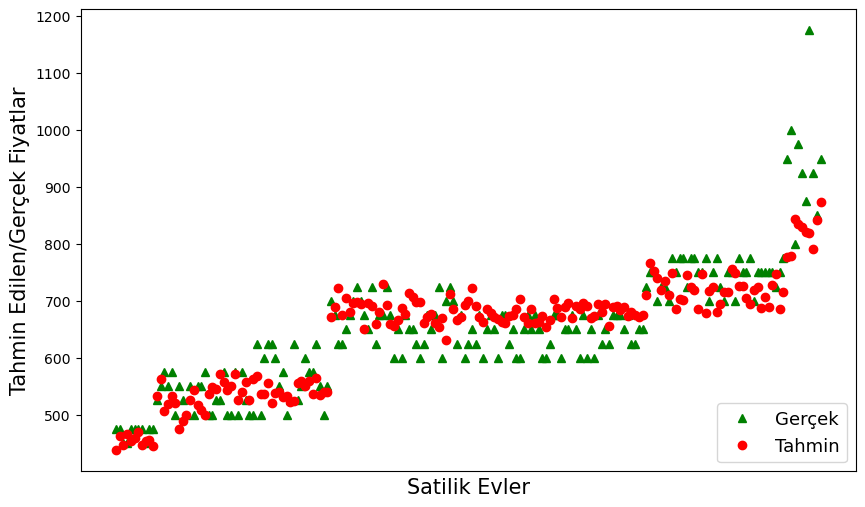

In [17]:
#Grafik: Evlerin gerçek ve tahmin edilmiş fiayatlarını karşılaştırılması:
plt.figure(figsize=(10,6))
plt.xticks(veri["Fiyat"],veri.index.values)
plt.plot(veri["Fiyat"],"g^",label="Gerçek")
plt.xticks(veri["Fiyat_Tahmini"],veri.index.values)
plt.plot(veri["Fiyat_Tahmini"],"ro",label="Tahmin")
plt.xlabel("Satilik Evler",fontsize=15)
plt.ylabel("Tahmin Edilen/Gerçek Fiyatlar",fontsize=15)
plt.legend(fontsize=13,loc="lower right")
plt.show()

In [18]:
Oda_sayisi=3
Net_m2=105
Kati=4
Yaşi=8
print("Yeni evin Fiyatı :",enet_gs.best_estimator_.predict([[Oda_sayisi,Net_m2,Kati,Yaşi]]))


Yeni evin Fiyatı : [768.41529786]


c:\Users\enesc\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(
